# Optimised Mesh Drawing

## Pre-processing

Module imports

In [1]:
import os
import sys

import numpy as np
import trimesh
from numba import njit

# --- Get PID ---
pid = print(f'PID: {os.getpid()}')

PID: 23849


Adding PATH 

In [2]:
# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root added to sys.path


Parsing `.gro` file (slightly slower method by accessing data from pandas df)

In [3]:
# Import module
from utils import gro_processing as gp

# Data directory can be accessed due to root PATH we set previously
file = os.path.join(project_root, 'data/npt-HK4.gro')

# Extracts data from .gro file into DataFrame (unsorted)
data, title, num_atoms, box_dimensions = gp.read_gro(file) 

# Parameter
box_length = box_dimensions[0]

# Create multi-index DataFrame (sorted)
df_gro = gp.dataframe_gro(data, box_length, positions=True, velocities=False, oxygen_midpoints=False)

# Dictionary of molecules {res_id: [(atom_name, np.array([x, y, z])), ...]}
molecules = {}

for res_id in df_gro.index.get_level_values('res_id').unique():
    residue_data = df_gro.xs(res_id, level='res_id')
    
    # Optional: verify we have 84 atoms
    if len(residue_data) != 84:
        print(f"Warning: res_id {res_id} has {len(residue_data)} atoms, expected 84")
    
    # Using itertuples() - much faster for large DataFrames
    atom_list = [
        (row.Index, np.array([row.x, row.y, row.z]) * 10)
        for row in residue_data.itertuples()
    ]
    
    molecules[res_id] = atom_list

In [4]:
box_dimensions = box_dimensions * 10
# molecules # display

## Setup

Optimized by:
- Using `hash_atom` (dictionary) lookup $\mathcal{O}(1),$ compared to array (list) lookup $\mathcal{O}(n)$. 

In [5]:
# --- CONFIG ---
gro_path = "./1mol.gro"                   
sphere_radius_scale = 2.0                # balls (atoms): 2.0 × van der Waals radius   # idk why 1.5 :(
bond_radius = 0.1                        # sticks (bonds): cylinder radius in Å
sphere_subdiv = 2                        # atom sphere detail (2 is moderate)

# --- Radii (Å) ---
vdw = {"H":1.20,"C":1.70,"N":1.55,"O":1.52,"F":1.47,"P":1.80,"S":1.80,"Cl":1.75,"Na":2.27,"K":2.75,"Ca":2.31}
cov = {"H":0.31,"C":0.76,"N":0.71,"O":0.66,"F":0.57,"P":1.07,"S":1.05,"Cl":1.02,"Na":1.66,"K":2.03,"Ca":1.74}

In [6]:
# --- Element inference ---
hash_atom = {"OW": "O", "HW": "H", "HW1": "H", "HW2": "H"} # Atom name aliases

def infer_element(atomname):
    # common water aliases
    if atomname in hash_atom: 
        return hash_atom[atomname]
    
    # simple: first letter, capitalize second if lowercase
    a = ''.join([c for c in atomname if c.isalpha()])   
    
    # join() joins items in an iterable into one string, '' is specified as the separator.
    # isalpha() method returns True if all the characters are alphabet letters (a-z).

    if a == '': 
        return "C"

    if len(a) >= 2 and a[1].islower(): 
        return (a[0]+a[1]).capitalize()
    
    return a[0].upper()

## Ball-and-stick molecule model

Optimised **sphere** by:
- Modified `mic_vector` function to accept `ndarray` as parameter.
- Cache base `icosphere` object and apply transformations on it (faster than creating).
- Chunking array for `icosphere` rather than append.

Optimised **cylinder** by:
- `numba`-ed 2 functions.
- Added k-d tree method for molecules with > 1500 atoms (otherwise slower, see [png file](./ratio-kdtree-bruteforce.png)).
- Did not use numpy vectorised method because takes a lot of memory.

In [7]:
# --- Minimum Image Convention (vector) ---
@njit(cache=True)
def mic_vector(dx, box_length):
    """Return minimum-image displacement for vector dx under PBC."""
    return dx - np.rint(dx / box_length) * box_length

@njit(cache=True)
def mic_distance(a, b, box_length):
    """Return MIC distance between two 3D points a,b."""
    return np.linalg.norm(mic_vector(b - a, box_length))

_ = mic_vector(np.array([8.0, 9.0, 10.0]), 10.0) 
_ = mic_distance(np.array([8.0, 9.0, 10.0]), np.array([1.0, 2.0, 3.0]), 10.0)

In [ ]:
from scipy.spatial import KDTree

# --- Build ball-and-stick with PBC ---
def build_molecule_ballstick(coords, elements, 
                             vdw, cov, 
                             box_length, 
                             sphere_radius_scale=0.3, 
                             sphere_subdiv=2, 
                             bond_radius=0.1):
    """
    Build trimesh ball-and-stick model under periodic boundary conditions.
    """

    # radii arrays
    vdw_r = np.array([vdw.get(e, 1.70) for e in elements])
    cov_r = np.array([cov.get(e, 0.76) for e in elements])
    
    n = len(coords)
    
    
    # --- Process spheres using chunking--- 
    # Base icosphere (unit radius)
    base_sphere = trimesh.creation.icosphere(subdivisions=sphere_subdiv, radius=1.0)
    # Precompute position and radii for each sphere
    coords_wrapped = np.mod(coords, box_length)
    scaled_radii = vdw_r * sphere_radius_scale  
    # Chunk (pre-allocate) array to hold icosphere object
    meshes_sphere = np.empty(len(coords_wrapped), dtype=object)
    
    for idx, (pos, r) in enumerate(zip(coords_wrapped, scaled_radii)):
        sphere = base_sphere.copy()
        sphere.apply_scale(r)
        sphere.apply_translation(pos)
        meshes_sphere[idx] = sphere
        
        
    # --- Process cylinder with numba --- 
    # For small molecules roughly < 1500, brute force is most efficient
    meshes_cylinder = []
    if n >= 1500: # k-d tree
        tree = KDTree(coords, leafsize=10)
        for i in range(n):
            _nearest_coords, nearest_index = tree.query(coords[i], k=9) # 8 neighbors
            for j in nearest_index[1:]: # Skip itself
                d = mic_distance(coords[i], coords[j], box_length)
                thr = 1.2 * (cov_r[i] + cov_r[j])
                if d < thr:
                    # Unwrap j relative to i
                    disp = mic_vector(coords[j] - coords[i], box_length)
                    pos_i = np.mod(coords[i], box_length)
                    pos_j = pos_i + disp # may fall outside box but correct bond vector
                    seg = np.vstack((pos_i, pos_j))
                    cyl = trimesh.creation.cylinder(radius=bond_radius,
                                                    segment=seg, sections=24)
                    meshes_cylinder.append(cyl)
    else: # brute force
        for i in range(n):
            for j in range(i+1, n):
                d = mic_distance(coords[i], coords[j], box_length)
                thr = 1.2 * (cov_r[i] + cov_r[j])
                if d < thr:
                    # Unwrap j relative to i
                    disp = mic_vector(coords[j] - coords[i], box_length)
                    pos_i = np.mod(coords[i], box_length)
                    pos_j = pos_i + disp  # may fall outside box but correct bond vector
                    seg = np.vstack((pos_i, pos_j))
                    cyl = trimesh.creation.cylinder(radius=bond_radius,
                                                    segment=seg, sections=24)
                    meshes_cylinder.append(cyl)


    return meshes_sphere.tolist() + meshes_cylinder

## Molecules to meshes

In [ ]:
def molecules_to_meshes(molecules, box,
                        vdw, cov,
                        sphere_radius_scale=0.3,
                        sphere_subdiv=2,
                        bond_radius=0.1):
    """
    Convert parsed molecules into trimesh meshes.

    Parameters
    ----------
    molecules : dict[int, list[tuple]]
        From parse_gro(): molecules[i] = [(atomname, coords), ...]
        coords must be in Å
    box : np.ndarray
        Simulation box (Å), shape (3,) for orthorhombic or (3,3) for triclinic
    vdw, cov : dict
        Van der Waals and covalent radii
    sphere_radius_scale : float
        Scaling factor for atom radii
    sphere_subdiv : int
        Subdivisions for icosphere (mesh resolution)
    bond_radius : float
        Cylinder radius for bonds

    Returns
    -------
    mol_meshes : dict[int, trimesh.Trimesh]
        Dictionary of molecule meshes keyed by mol_id
    """
    
    mol_meshes = {}
    # assume orthorhombic box for now
    if box.shape == (3,):
        box_length = box
    else:
        raise NotImplementedError("Triclinic box handling not yet implemented")
    
    for mol_id, atoms in molecules.items():
        elements = [infer_element(name) for name, _ in atoms]
        coords = np.vstack([pos for _, pos in atoms])
        # print(f'Molecule: {mol_id}')
        
        mesh = build_molecule_ballstick(
            coords, elements, vdw, cov, box_length,
            sphere_radius_scale=sphere_radius_scale,
            sphere_subdiv=sphere_subdiv,
            bond_radius=bond_radius
        )
        mol_meshes[mol_id] = mesh
    
    return mol_meshes

1501
[<trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(50, 3), faces.shape=(96, 3))>, <trimesh.Trimesh(vertices.shape=(5

In [ ]:
# Now mol_meshes is {1: Trimesh(...), 2: Trimesh(...), ..., 1501: Trimesh(...)}
mol_meshes = molecules_to_meshes(molecules, box_dimensions, vdw, cov)
print(len(mol_meshes))        # 1501
print(mol_meshes[1])          # trimesh.Trimesh object

## Visualisation

In [10]:
scene = trimesh.Scene(list(mol_meshes.values())[0:30])
scene.show()

---

## Extra: Testing KD-Tree Speed

Just extra part to compare the speed between KD-Tree and Brute-Force. Can ignore this part.

Running simulations for different n values...
Testing n=10...
Testing n=50...
Testing n=100...
Testing n=200...
Testing n=300...
Testing n=400...
Testing n=500...
Testing n=600...
Testing n=700...
Testing n=800...
Testing n=900...
Testing n=1000...
Testing n=1500...
Testing n=2000...
Testing n=4000...

Simulations completed!


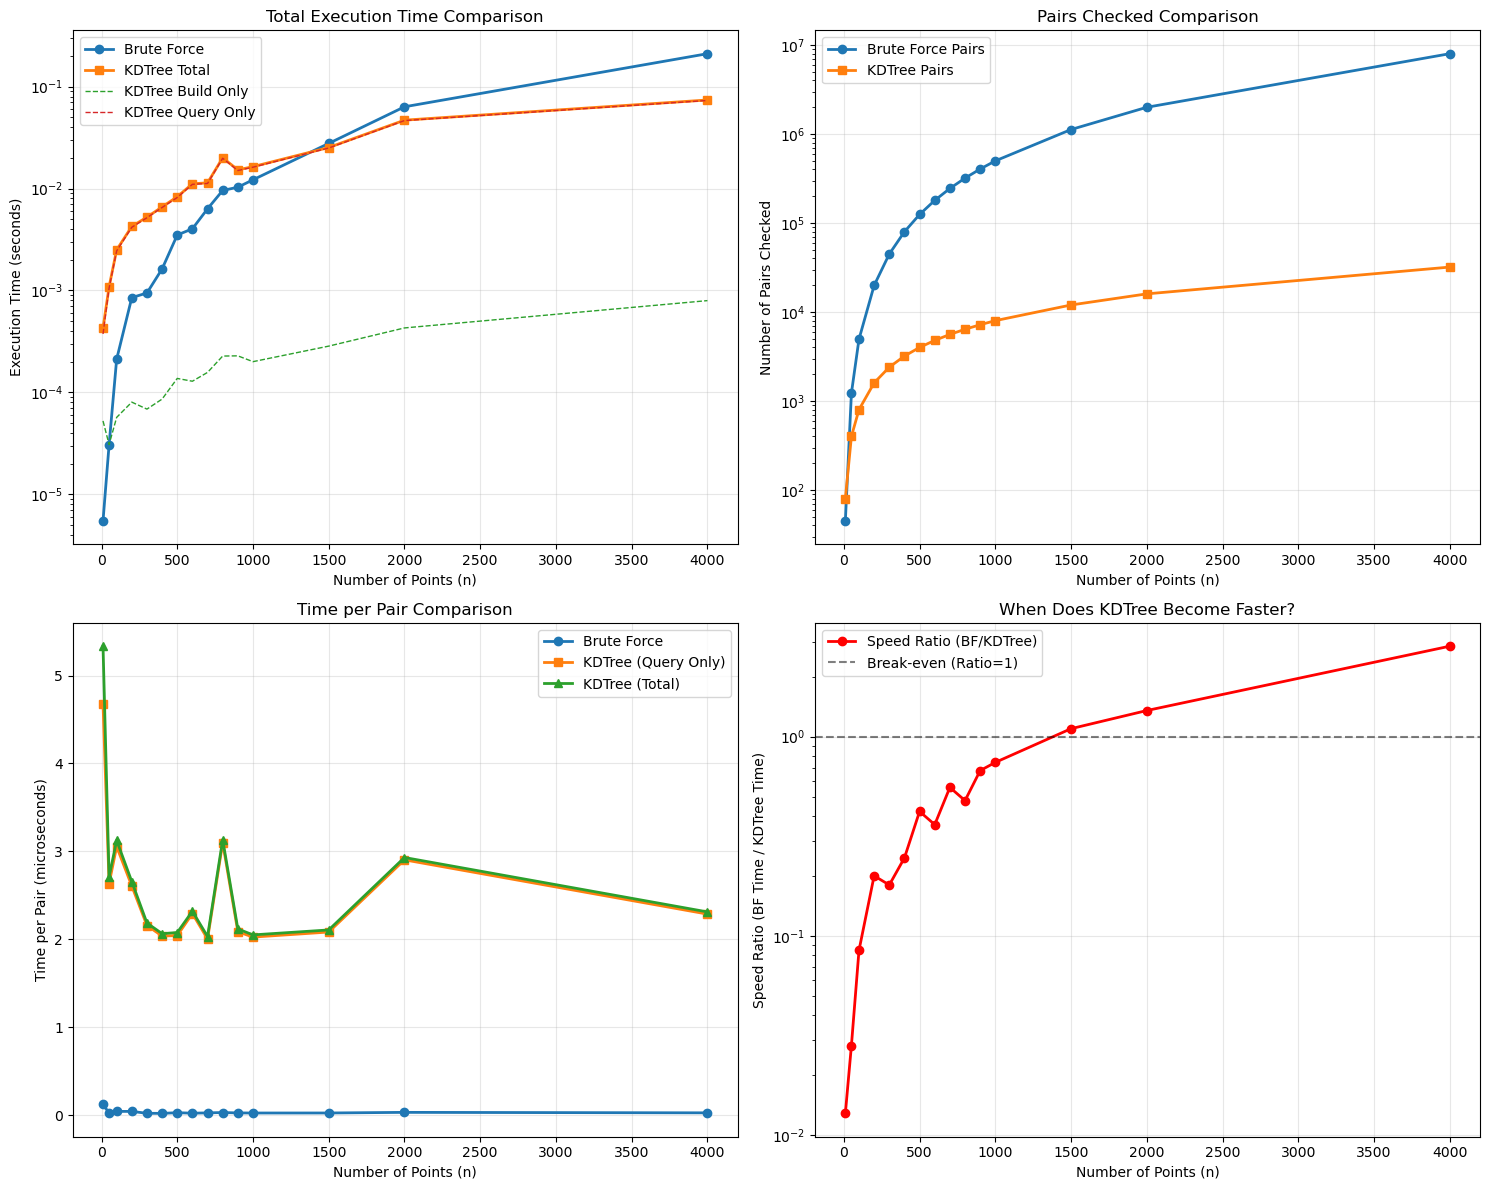


=== SUMMARY TABLE ===
     n BF Time(s) KD Time(s)    Ratio   BF Pairs   KD Pairs Pairs Ratio
--------------------------------------------------------------------------------
    10     0.0000     0.0004     0.01         45         80        0.6
    50     0.0000     0.0011     0.03       1225        400        3.1
   100     0.0002     0.0025     0.08       4950        800        6.2
   200     0.0009     0.0043     0.20      19900       1600       12.4
   300     0.0009     0.0052     0.18      44850       2400       18.7
   400     0.0016     0.0066     0.25      79800       3200       24.9
   500     0.0035     0.0083     0.42     124750       4000       31.2
   600     0.0040     0.0111     0.36     179700       4800       37.4
   700     0.0063     0.0114     0.56     244650       5600       43.7
   800     0.0096     0.0201     0.48     319600       6400       49.9
   900     0.0103     0.0152     0.68     404550       7200       56.2
  1000     0.0122     0.0164     0.74     4

In [ ]:
import time
import numpy as np
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

def simulate_brute_force(n):
    """Simulate just the double loop overhead"""
    start = time.time()
    pairs_checked = 0
    for i in range(n):
        for j in range(i+1, n):
            pairs_checked += 1
            # Simulate a simple distance check (no actual calculation)
            if False:  # This never executes, just for structure
                pass
    end = time.time()
    return end - start, pairs_checked

def simulate_kdtree(n):
    """Simulate KDTree construction + query overhead"""
    # Generate dummy coordinates
    coords = np.random.rand(n, 3)
    
    # Measure KDTree construction
    start_build = time.time()
    tree = KDTree(coords, leafsize=10)
    build_time = time.time() - start_build
    
    # Measure query overhead
    start_query = time.time()
    pairs_checked = 0
    for i in range(n):
        # Simulate KDTree query
        _nearest_coords, nearest_index = tree.query(coords[i], k=9)
        
        for j in nearest_index[1:]:  # Skip itself
            if j >= n:  # Safety check
                continue
            pairs_checked += 1
            # Simulate a simple distance check (no actual calculation)
            if False:  # This never executes, just for structure
                pass
    query_time = time.time() - start_query
    
    total_time = build_time + query_time
    return total_time, pairs_checked, build_time, query_time

# Test different n values
n_values = [10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1500, 2000, 4000]
# n_values = [10, 50, 100, 200, 500, 1000, 2000]  # Smaller set for quick testing

# Storage for results
results = {
    'n': [],
    'bf_time': [], 'bf_pairs': [], 'bf_time_per_pair': [],
    'kd_total_time': [], 'kd_pairs': [], 'kd_build_time': [], 'kd_query_time': [],
    'kd_time_per_pair_query': [], 'kd_time_per_pair_total': [],
    'speed_ratio': [], 'pairs_ratio': []
}

print("Running simulations for different n values...")
for n in n_values:
    print(f"Testing n={n}...")
    
    # Brute force
    bf_time, bf_pairs = simulate_brute_force(n)
    
    # KDTree (average of 3 runs for stability)
    kd_times = []
    kd_pairs_list = []
    kd_build_times = []
    kd_query_times = []
    
    for _ in range(3):  # Average 3 runs
        kd_total, kd_pairs, kd_build, kd_query = simulate_kdtree(n)
        kd_times.append(kd_total)
        kd_pairs_list.append(kd_pairs)
        kd_build_times.append(kd_build)
        kd_query_times.append(kd_query)
    
    kd_time = np.mean(kd_times)
    kd_pairs_val = np.mean(kd_pairs_list)
    kd_build = np.mean(kd_build_times)
    kd_query = np.mean(kd_query_times)
    
    # Store results
    results['n'].append(n)
    results['bf_time'].append(bf_time)
    results['bf_pairs'].append(bf_pairs)
    results['bf_time_per_pair'].append(bf_time/bf_pairs*1e6 if bf_pairs > 0 else 0)
    
    results['kd_total_time'].append(kd_time)
    results['kd_pairs'].append(kd_pairs_val)
    results['kd_build_time'].append(kd_build)
    results['kd_query_time'].append(kd_query)
    results['kd_time_per_pair_query'].append(kd_query/kd_pairs_val*1e6 if kd_pairs_val > 0 else 0)
    results['kd_time_per_pair_total'].append(kd_time/kd_pairs_val*1e6 if kd_pairs_val > 0 else 0)
    
    results['speed_ratio'].append(bf_time/kd_time if kd_time > 0 else float('inf'))
    results['pairs_ratio'].append(bf_pairs/kd_pairs_val if kd_pairs_val > 0 else float('inf'))

print("\nSimulations completed!")

# Create plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Total execution time
ax1.plot(results['n'], results['bf_time'], 'o-', label='Brute Force', linewidth=2, markersize=6)
ax1.plot(results['n'], results['kd_total_time'], 's-', label='KDTree Total', linewidth=2, markersize=6)
ax1.plot(results['n'], results['kd_build_time'], '--', label='KDTree Build Only', linewidth=1)
ax1.plot(results['n'], results['kd_query_time'], '--', label='KDTree Query Only', linewidth=1)
ax1.set_xlabel('Number of Points (n)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Total Execution Time Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Plot 2: Number of pairs checked
ax2.plot(results['n'], results['bf_pairs'], 'o-', label='Brute Force Pairs', linewidth=2, markersize=6)
ax2.plot(results['n'], results['kd_pairs'], 's-', label='KDTree Pairs', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Points (n)')
ax2.set_ylabel('Number of Pairs Checked')
ax2.set_title('Pairs Checked Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

# Plot 3: Time per pair
ax3.plot(results['n'], results['bf_time_per_pair'], 'o-', label='Brute Force', linewidth=2, markersize=6)
ax3.plot(results['n'], results['kd_time_per_pair_query'], 's-', label='KDTree (Query Only)', linewidth=2, markersize=6)
ax3.plot(results['n'], results['kd_time_per_pair_total'], '^-', label='KDTree (Total)', linewidth=2, markersize=6)
ax3.set_xlabel('Number of Points (n)')
ax3.set_ylabel('Time per Pair (microseconds)')
ax3.set_title('Time per Pair Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Speed ratio
ax4.plot(results['n'], results['speed_ratio'], 'o-', label='Speed Ratio (BF/KDTree)', linewidth=2, markersize=6, color='red')
ax4.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Break-even (Ratio=1)')
ax4.set_xlabel('Number of Points (n)')
ax4.set_ylabel('Speed Ratio (BF Time / KDTree Time)')
ax4.set_title('When Does KDTree Become Faster?')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')

plt.tight_layout()
plt.show()

# Print summary table
print("\n=== SUMMARY TABLE ===")
print(f"{'n':>6} {'BF Time(s)':>10} {'KD Time(s)':>10} {'Ratio':>8} {'BF Pairs':>10} {'KD Pairs':>10} {'Pairs Ratio':>10}")
print("-" * 80)
for i in range(len(results['n'])):
    n = results['n'][i]
    bf_t = results['bf_time'][i]
    kd_t = results['kd_total_time'][i]
    ratio = results['speed_ratio'][i]
    bf_p = int(results['bf_pairs'][i])
    kd_p = int(results['kd_pairs'][i])
    p_ratio = results['pairs_ratio'][i]
    
    print(f"{n:>6} {bf_t:>10.4f} {kd_t:>10.4f} {ratio:>8.2f} {bf_p:>10} {kd_p:>10} {p_ratio:>10.1f}")

# Find crossover point
crossover_n = None
for i in range(1, len(results['n'])):
    if results['speed_ratio'][i-1] > 1 and results['speed_ratio'][i] <= 1:
        crossover_n = results['n'][i]
        break

if crossover_n:
    print(f"\n*** KDTree becomes faster at n ≈ {crossover_n} ***")
else:
    # Check if KDTree is always faster or never faster
    if all(r <= 1 for r in results['speed_ratio']):
        print(f"\n*** KDTree is faster for all tested n values ***")
    elif all(r >= 1 for r in results['speed_ratio']):
        max_n = max(results['n'])
        print(f"\n*** KDTree is still slower at n={max_n}, crossover point is above {max_n} ***")